Accelerator use is GPU T4 x2 in Kaggle

# **Data Collection and Download**

Humans in the Loop is publishing an open access dataset annotated for a joint project with the Mohammed Bin Rashid Space Center in Dubai, the UAE . The dataset consists of aerial imagery of Dubai obtained by MBRSC satellites and annotated with pixel-wise semantic segmentation in 6 classes. The total volume of the dataset is 48 images grouped into 6 larger tiles. The classes are:

Building: #3C1098

Land (unpaved area): #8429F6

Road: #6EC1E4

Vegetation: #FEDD3A

Water: #E2A929

Unlabeled: #9B9B9B

dataset link : https://www.kaggle.com/datasets/muhammadyasirsaleem/satellite-imagery

# **Install Libraries and Dependencies**

In [ ]:
!pip install huggingface_hub==0.19.4 segmentation-models-pytorch --upgrade

In [1]:
import os
import cv2
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from skimage.exposure import match_histograms
import segmentation_models_pytorch as smp

2026-03-21 06:12:40.263045: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-21 06:12:40.263188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-21 06:12:40.404489: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **Acessing Dataset, Histogram Matching and Patching Data**

In [2]:
root_directory = "/kaggle/input/satellite-imagery/Data/aerial imagery"
patch_size = 256

In [3]:


image_dataset = []
mask_dataset = []

reference_img = None  

for path, subdirs, files in os.walk(root_directory):
    dirname = path.split(os.path.sep)[-1]

    if dirname == 'images':
        images = sorted([f for f in files if f.endswith(".jpg")])
        mask_path = os.path.join(os.path.dirname(path), 'masks')
        masks = sorted([f for f in os.listdir(mask_path) if f.endswith(".png")])

        for img_name, mask_name in zip(images, masks):

            image = cv2.imread(os.path.join(path, img_name), 1)
            mask = cv2.imread(os.path.join(mask_path, mask_name), 1)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)


            if reference_img is None:
                reference_img = image.copy()

            image = match_histograms(image, reference_img, channel_axis=-1)

       
            image = np.clip(image, 0, 255).astype(np.uint8)

            SIZE_X = (image.shape[1] // patch_size) * patch_size
            SIZE_Y = (image.shape[0] // patch_size) * patch_size

            image = image[:SIZE_Y, :SIZE_X, :]
            mask  = mask[:SIZE_Y, :SIZE_X, :]

           
            for i in range(0, SIZE_Y, patch_size):
                for j in range(0, SIZE_X, patch_size):

                    image_dataset.append(image[i:i+patch_size, j:j+patch_size, :])
                    mask_dataset.append(mask[i:i+patch_size, j:j+patch_size, :])

image_dataset = np.array(image_dataset)
mask_dataset  = np.array(mask_dataset)

Mask file chosen: image_part_001.png
Mask shape: (644, 797, 3)
Mask dtype: uint8
Unique raw values in mask: [ 16  41  58  60 110 132 152 155 169 193 221 226 228 246 254]


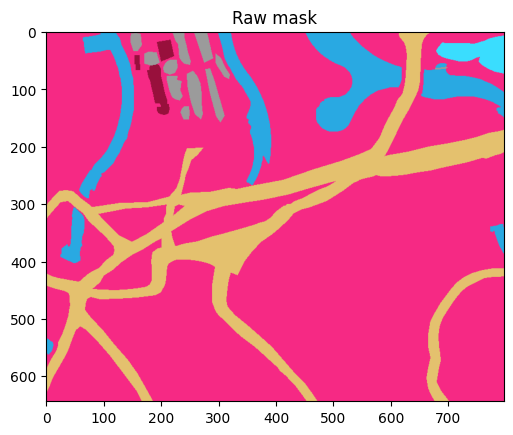

In [51]:
mask_path = '/kaggle/input/satellite-imagery/Data/aerial imagery/Tile 1/masks'
mask_files = sorted([f for f in os.listdir(mask_path) if f.endswith('.png')])
mask_file = mask_files[0]
print("Mask file chosen:", mask_file)
mask = cv2.imread(os.path.join(mask_path, mask_file), cv2.IMREAD_UNCHANGED)
print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)
print("Unique raw values in mask:", np.unique(mask))
plt.imshow(mask)
plt.title("Raw mask")
plt.show()

# **Data Visualization of dataset**

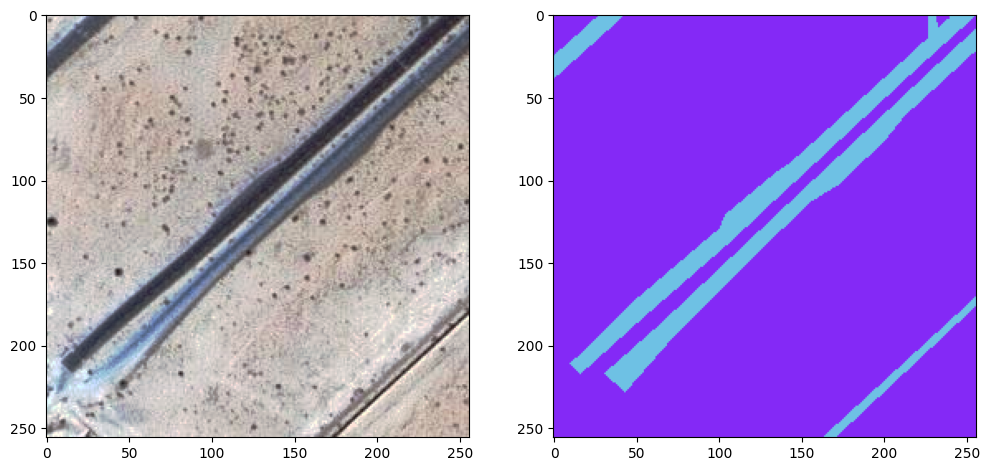

In [6]:
image_number = random.randint(0, len(image_dataset))

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(image_dataset[image_number])
plt.subplot(122)
plt.imshow(mask_dataset[image_number])
plt.show()

# **Masks Encoding**

In the context of semantic segmentation, masks are typically represented as images where each pixel corresponds to a specific class or category .

creating masks for image segmentation tasks where different classes (like buildings, land, roads, vegetation, water, and unlabeled areas) are represented by specific colors. The conversion allows these masks to be processed numerically in subsequent image processing .

In [4]:
# converting hexadecimal color codes into RGB arrays using NumPy.

#Each pixel in the segmentation mask corresponds to a class, and each class is represented by a unique color

Building = '#3C1098'.lstrip('#')
Building = np.array(tuple(int(Building[i:i+2], 16) for i in (0, 2, 4))) # 60, 16, 152

Land = '#8429F6'.lstrip('#')
Land = np.array(tuple(int(Land[i:i+2], 16) for i in (0, 2, 4))) #132, 41, 246

Road = '#6EC1E4'.lstrip('#')
Road = np.array(tuple(int(Road[i:i+2], 16) for i in (0, 2, 4))) #110, 193, 228

Vegetation =  'FEDD3A'.lstrip('#')
Vegetation = np.array(tuple(int(Vegetation[i:i+2], 16) for i in (0, 2, 4))) #254, 221, 58

Water = 'E2A929'.lstrip('#')
Water = np.array(tuple(int(Water[i:i+2], 16) for i in (0, 2, 4))) #226, 169, 41

Unlabeled = '#9B9B9B'.lstrip('#')
Unlabeled = np.array(tuple(int(Unlabeled[i:i+2], 16) for i in (0, 2, 4))) #155, 155, 155

This conversion is essential for training segmentation models, which typically expect integer labels rather than RGB values. The final dataset (labels) contains these 2D label masks.

In [5]:
def rgb_to_2D_label(label):
    label_seg = np.zeros((label.shape[0], label.shape[1]), dtype=np.uint8)

    label_seg[np.all(label == Unlabeled, axis=-1)] = 0
    label_seg[np.all(label == Land, axis=-1)] = 1
    label_seg[np.all(label == Road, axis=-1)] = 2
    label_seg[np.all(label == Vegetation, axis=-1)] = 3
    label_seg[np.all(label == Water, axis=-1)] = 4
    label_seg[np.all(label == Building, axis=-1)] = 5

    return label_seg

labels = []
for i in range(mask_dataset.shape[0]):
    label = rgb_to_2D_label(mask_dataset[i])
    labels.append(label)


labels = np.array(labels)


print("Unique labels in label dataset are: ", np.unique(labels))


Unique labels in label dataset are:  [0 1 2 3 4 5]


In [6]:
def simulate_point_labels(label_mask, num_points_per_class=10):
    "randomly sample point labels"

    H, W= label_mask.shape

    point_mask = np.full((H, W), -1, dtype=np.int64)

    
    num_classes = 6 
    for cls_id in range(num_classes):

        positions = np.argwhere(label_mask == cls_id)  
       
        
        if len(positions) == 0:
            continue  
        
    
        n_sample = min(num_points_per_class, len(positions))
        chosen_indices = np.random.choice(len(positions), n_sample, replace=False)
        chosen_positions = positions[chosen_indices]
        for (r, c) in chosen_positions:
            point_mask[r, c] = cls_id

  
    return point_mask

# **Image Augmentation**

In [7]:
def get_train_augs():
    albumentations_transform = [
        A.HorizontalFlip(),
        A.VerticalFlip(),
        A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ToTensorV2()
    ]
    return A.Compose(albumentations_transform)


def get_valid_augs():
    return A.Compose([
        A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ToTensorV2()
    ])

In [8]:
class RemoteSensingDataset(Dataset):
    def __init__(self, images, point_labels, transform=None):
        self.images = images
        self.point_labels = point_labels 
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]  
        label = self.point_labels[idx]  
        
        if self.transform:
            augmented = self.transform(image=image, mask=label)
            image = augmented['image']
            label = augmented['mask']
        
        return image, label

# **Partial Cross Entropy loss and mIoU**

Partial Cross Entropy Loss (PCE) is a modification of the standard Cross Entropy Loss (CE) designed to address class imbalance in classification task . This helps prevent the dominant class from overshadowing the minority classes in the training process, especially when dealing with imbalanced dataset . Partial Cross Entropy Loss provides a more informative and balanced signal to the model, potentially improving its ability to learn from imbalanced datasets 

In [10]:
import torch
import torch.nn as nn

class PartialCrossEntropyLoss(nn.Module):
    def __init__(self, ignore_index=-1, num_classes=6):
        super().__init__()
    
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=ignore_index)
    
    def forward(self, predictions, targets):
 
        return self.loss_fn(predictions, targets)


In [11]:
def calculate_mIoU(preds, masks, num_classes=6, ignore_index=-1):
    preds = torch.argmax(preds, dim=1) 
    mIoU = 0
    valid_classes = 0


    mask_valid = (masks != ignore_index)

    for cls in range(num_classes):

        mask_cls = (masks == cls) & mask_valid
        if mask_cls.sum() == 0:
            continue  

        pred_cls = (preds == cls) & mask_valid

        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()

        if union > 0:
            mIoU += intersection / union
            valid_classes += 1

    return mIoU / max(valid_classes, 1)

# **Import Model for Transfer Learning**

In [13]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model_a = smp.Unet(encoder_name="resnet50", classes=6).to(device)
# checkpoint = torch.load("/kaggle/input/datasets/faradayotuoniyo/resnet50checkpoint/checkpoint.pth")
# model_a.load_state_dict(checkpoint["model_state_dict"])
# model_a.eval()

model_a = smp.Unet(
    encoder_name="resnet50",       
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=6,                      
    activation=None                 
)

model_b = smp.Unet(
    encoder_name="efficientnet-b0",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=6,                      
    activation=None                 
)

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 252MB/s]
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 122MB/s] 


# **Training Loop**

In [52]:
def generate_point_dataset(labels, num_points):
    return np.array([
        simulate_point_labels(labels[i], num_points_per_class=num_points)
        for i in range(len(labels))
    ])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def run_experiment(num_points, confidence_threshold):
    print(f"\nRunning experiment: Points={num_points}, Threshold={confidence_threshold}")


    point_labels = generate_point_dataset(labels, num_points)


    X_train, X_test, y_train, y_test = train_test_split(
        image_dataset, point_labels, test_size=0.20, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=42
    )


    trainDataset = RemoteSensingDataset(X_train, y_train, get_train_augs())
    valDataset   = RemoteSensingDataset(X_val, y_val, get_valid_augs())

    trainLoader = DataLoader(trainDataset, batch_size=8, shuffle=True)
    valLoader   = DataLoader(valDataset, batch_size=8, shuffle=False)

   
    model_a = smp.Unet(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=6,
        activation=None
    ).to(device)

    model_b = smp.Unet(
        encoder_name="efficientnet-b0",
        encoder_weights="imagenet",
        in_channels=3,
        classes=6,
        activation=None
    ).to(device)

    optimizer_a = torch.optim.Adam(model_a.parameters(), lr=1e-4)
    optimizer_b = torch.optim.Adam(model_b.parameters(), lr=1e-4)
    criterion = PartialCrossEntropyLoss(ignore_index=-1)

    num_epochs = 10


    train_losses, val_losses = [], []
    train_mIoUs, val_mIoUs = [], []

    def ensemble_preds(images):
       
        return (model_a(images) + model_b(images)) / 2

    #Training
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model_a.train()
        model_b.train()
        train_loss = 0

        for images, masks in tqdm(trainLoader, desc="Supervised batches"):
            images = images.float().to(device)
            masks  = masks.long().to(device)

            preds = ensemble_preds(images)
            loss  = criterion(preds, masks)

            optimizer_a.zero_grad()
            optimizer_b.zero_grad()
            loss.backward()
            optimizer_a.step()
            optimizer_b.step()

            train_loss += loss.item()
                # Average training loss
        train_loss /= len(trainLoader)
        train_losses.append(train_loss)

        #training mIoU
        model_a.eval()
        model_b.eval()
        train_mIoU = 0
        with torch.no_grad():
            for images, masks in trainLoader:
                images = images.float().to(device)
                masks  = masks.long().to(device)
                preds  = ensemble_preds(images)
                train_mIoU += calculate_mIoU(preds, masks)
        train_mIoU /= len(trainLoader)
        train_mIoUs.append(train_mIoU)
            
        print(f"  Supervised Train Loss: {train_loss:.4f}, Train mIoU: {train_mIoU:.4f}")
        # semi-supervised
        if epoch >= 5:
            model_a.train()
            model_b.train()
            pseudo_train_loss=0
            for images, masks in tqdm(trainLoader, desc="Pseudo-label batches"):
                images = images.float().to(device)
                masks  = masks.long().to(device)

                with torch.no_grad():
                    pseudo_probs = torch.softmax(ensemble_preds(images), dim=1)
                    # print(f' pseudo: {pseudo_probs}')
                    confidence, pseudo_labels = pseudo_probs.max(dim=1)

                unlabeled = (masks == -1)
                reliable  = (confidence >= confidence_threshold)
                # print("Unlabeled pixels:", unlabeled.sum().item())
                # print("Reliable pixels:", reliable.sum().item())
                # print("Pseudo usable:", (unlabeled & reliable).sum().item())
                pseudo_mask = torch.where(
                    unlabeled & reliable,
                    pseudo_labels,
                    torch.full_like(masks, -1)
                )

                preds      = ensemble_preds(images)      
                supervised = criterion(preds, masks)
                pseudo_loss = criterion(preds, pseudo_mask)
                loss = supervised + 0.5 * pseudo_loss

                optimizer_a.zero_grad()
                optimizer_b.zero_grad()
                loss.backward()
                optimizer_a.step()
                optimizer_b.step()

                pseudo_train_loss += loss.item()
            print(f"  Pseudo-label Train Loss: {pseudo_train_loss/len(trainLoader):.4f}")

        # validation 
        model_a.eval()
        model_b.eval()
        val_loss = 0
        val_mIoU = 0

        with torch.no_grad():
            for images, masks in tqdm(valLoader, desc="Validation batches"):
                images = images.float().to(device)
                masks  = masks.long().to(device)

                preds = ensemble_preds(images)
                val_loss += criterion(preds, masks).item()
                val_mIoU += calculate_mIoU(preds, masks)

        val_loss /= len(valLoader)
        val_mIoU /= len(valLoader)
        val_losses.append(val_loss)
        val_mIoUs.append(val_mIoU)
        print(f"  Validation Loss: {val_loss:.4f}, Validation mIoU: {val_mIoU:.4f}")

    print(f"Final Val Loss: {val_loss:.4f}")
    return val_losses, val_mIoUs, train_losses, train_mIoUs, model_a, model_b

In [53]:
results = []

point_options = [1, 5, 10]
threshold_options = [0.7, 0.9]

for p in point_options:
    for t in threshold_options:
        val_losses, val_mIoUs, train_losses, train_mIoUs, model_a, model_b = run_experiment(p, t)
   
        results.append({
            'points': p,
            'threshold': t,
            'train_losses': train_losses,
            'train_mIoUs': train_mIoUs,
            'val_losses': val_losses,
            'val_mIoUs': val_mIoUs,
            'model_a': model_a,
            'model_b': model_b
        })

print("\nFinal Results:")
# for r in results:
#     print(f"Points={r[0]}, Threshold={r[1]} → Val Loss={r[2]:.4f}")


Running experiment: Points=1, Threshold=0.7

Epoch 1/10


Supervised batches: 100%|██████████| 40/40 [00:13<00:00,  2.91it/s]


  Supervised Train Loss: 1.8116, Train mIoU: 0.1383


Validation batches: 100%|██████████| 5/5 [00:00<00:00, 10.53it/s]


  Validation Loss: 1.7920, Validation mIoU: 0.1375

Epoch 2/10


...

  Supervised Train Loss: 0.7568, Train mIoU: 0.5938


Pseudo-label batches: 100%|██████████| 40/40 [00:17<00:00,  2.33it/s]


  Pseudo-label Train Loss: 0.7644


Validation batches: 100%|██████████| 5/5 [00:00<00:00, 11.31it/s]

  Validation Loss: 0.9996, Validation mIoU: 0.4717
Final Val Loss: 0.9996

Final Results:


In [45]:
#saving best model
torch.save({
    'model_a_state_dict': results[-1]['model_a'].state_dict(),
    'model_b_state_dict': results[-1]['model_b'].state_dict(),
    'epoch': 20,
}, '/kaggle/working/checkpoint.pth')

In [48]:
for r in results:
    print(f"points: {r['points']}, threshold: {r['threshold']}")

points: 1, threshold: 0.7
points: 1, threshold: 0.9
points: 5, threshold: 0.7
points: 5, threshold: 0.9
points: 10, threshold: 0.7
points: 10, threshold: 0.9


In [55]:
import pandas as pd

rows = []

for r in results:
    row = {
        "points": r["points"],
        "threshold": r["threshold"],
        "final_train_loss": r["train_losses"][-1],
        "final_val_loss": r["val_losses"][-1],
        "final_train_mIoU": r["train_mIoUs"][-1],
        "final_val_mIoU": r["val_mIoUs"][-1],
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

,points,threshold,final_train_loss,final_val_loss,final_train_mIoU,final_val_mIoU
0,1,0.7,0.931162,1.172489,0.531675,0.399101
1,1,0.9,0.931338,1.181016,0.575649,0.419105
2,5,0.7,0.765999,1.045629,0.620221,0.445439
3,5,0.9,0.759659,0.944853,0.600765,0.482634
4,10,0.7,0.732020,0.880499,0.638420,0.496027
5,10,0.9,0.756819,0.999607,0.593771,0.471677


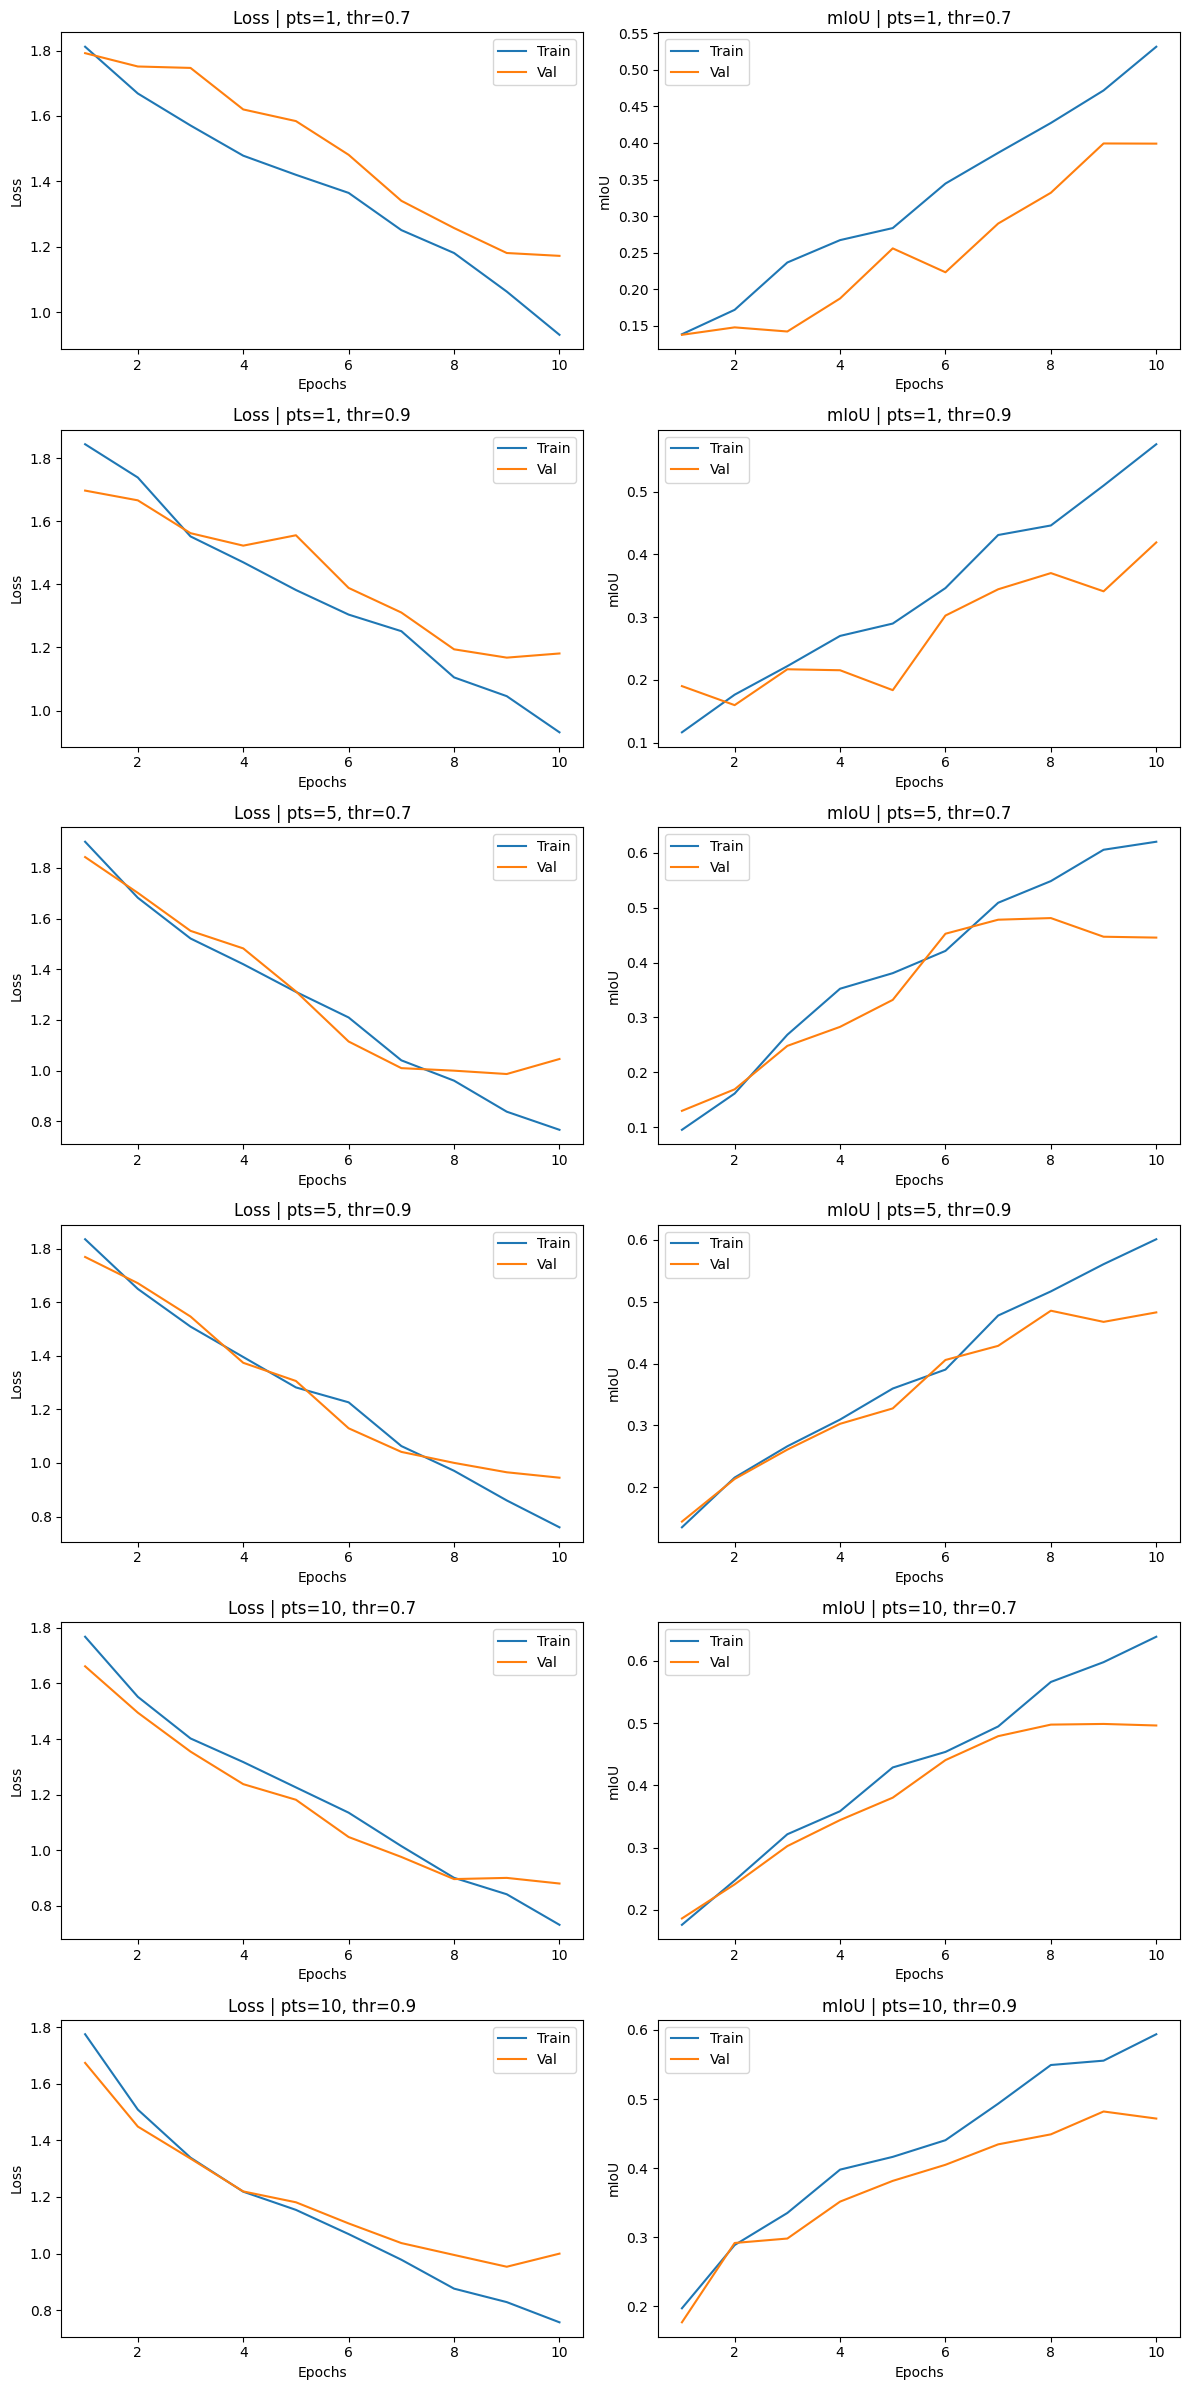

In [56]:
import matplotlib.pyplot as plt

num_experiments = len(results)

fig, axes = plt.subplots(num_experiments, 2, figsize=(12, 4 * num_experiments))


if num_experiments == 1:
    axes = [axes]

for i, data in enumerate(results):
    train_losses = data['train_losses']
    val_losses   = data['val_losses']
    train_miou   = data['train_mIoUs']
    val_miou     = data['val_mIoUs']

    epochs = range(1, len(train_losses) + 1)

    # lossess plot
    axes[i][0].plot(epochs, train_losses, label='Train')
    axes[i][0].plot(epochs, val_losses, label='Val')
    axes[i][0].set_title(f'Loss | pts={data["points"]}, thr={data["threshold"]}')
    axes[i][0].set_xlabel('Epochs')
    axes[i][0].set_ylabel('Loss')
    axes[i][0].legend()

    #miou plot
    axes[i][1].plot(epochs, train_miou, label='Train')
    axes[i][1].plot(epochs, val_miou, label='Val')
    axes[i][1].set_title(f'mIoU | pts={data["points"]}, thr={data["threshold"]}')
    axes[i][1].set_xlabel('Epochs')
    axes[i][1].set_ylabel('mIoU')
    axes[i][1].legend()

plt.tight_layout()
plt.show()

# **Test and Inference**

In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
from torch.utils.data import DataLoader


CLASS_COLORS = np.array([
    [60,  16,  152],   # CLass for Building
    [132, 41,  246],   #  class for Land
    [110, 193, 228],   # class  Road
    [254, 221, 58 ],   # class Vegetation
    [226, 169, 41 ],   # class Water
    [155, 155, 155],   # unlabeled class
], dtype=np.uint8)

CLASS_NAMES = ["Building", "Land", "Road", "Vegetation", "Water", "Unlabeled"]

def mask_to_rgb(mask):

    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_idx, color in enumerate(CLASS_COLORS):
        rgb[mask == cls_idx] = color
    return rgb

def ensemble_preds_tta(images, model_a, model_b, tta_transforms, device):

    preds_a = torch.zeros(images.shape[0], 6, images.shape[2], images.shape[3]).to(device)
    preds_b = torch.zeros_like(preds_a)

    for transform in tta_transforms:
        aug_images = transform.augment_image(images)

        out_a = model_a(aug_images)
        out_b = model_b(aug_images)

        preds_a += transform.deaugment_mask(torch.softmax(out_a, dim=1))
        preds_b += transform.deaugment_mask(torch.softmax(out_b, dim=1))

    preds_a /= len(tta_transforms)
    preds_b /= len(tta_transforms)

    return (preds_a + preds_b) / 2 


def run_inference_on_test(
    X_test, y_test,
    model_a, model_b,
    tta_transforms,
    device,
    num_display=10,
    batch_size=8
):

    testDataset = RemoteSensingDataset(X_test, y_test, get_valid_augs())
    testLoader  = DataLoader(testDataset, batch_size=batch_size, shuffle=False)

    model_a.eval()
    model_b.eval()

    criterion  = PartialCrossEntropyLoss(ignore_index=-1)
    test_loss  = 0
    test_mIoU  = 0

    all_preds = []   
    all_masks = []   

    with torch.no_grad():
        for images, masks in tqdm(testLoader, desc="Test inference"):
            images = images.float().to(device)
            masks  = masks.long().to(device)

    
            probs = ensemble_preds_tta(images, model_a, model_b, tta_transforms, device)


            preds_cls = probs.argmax(dim=1)   

            test_loss += criterion(probs, masks).item()
            test_mIoU += calculate_mIoU(probs, masks)


            all_preds.append(preds_cls.cpu().numpy())
            all_masks.append(masks.cpu().numpy())

    test_loss /= len(testLoader)
    test_mIoU /= len(testLoader)

    print(f"\n{'='*45}")
    print(f"  Test Loss : {test_loss:.4f}")
    print(f"  Test mIoU : {test_mIoU:.4f}")
    print(f"{'='*45}\n")

   
    all_preds = np.concatenate(all_preds, axis=0)   
    all_masks = np.concatenate(all_masks, axis=0)   


    _visualize_predictions(all_preds, all_masks, num_display)

    return test_mIoU, test_loss


def _visualize_predictions(all_preds, all_masks, num_display=10):

    num_display = min(num_display, len(all_preds))

    fig, axes = plt.subplots(num_display, 2, figsize=(10, num_display * 3))
    fig.suptitle("Predicted (Left)  vs  Ground Truth (Right)", fontsize=14, fontweight='bold', y=1.01)

    for i in range(num_display):
        pred_rgb = mask_to_rgb(all_preds[i])

       
        display_mask = all_masks[i].copy()
        display_mask[display_mask == -1] = 0
        gt_rgb = mask_to_rgb(display_mask)

        axes[i, 0].imshow(pred_rgb)
        axes[i, 0].set_title(f"Sample {i+1} — Predicted", fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_rgb)
        axes[i, 1].set_title(f"Sample {i+1} — Ground Truth", fontsize=9)
        axes[i, 1].axis('off')

 
    patches = [
        mpatches.Patch(color=np.array(CLASS_COLORS[c]) / 255, label=CLASS_NAMES[c])
        for c in range(len(CLASS_NAMES))
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.02), fontsize=9, title="Classes")

    plt.tight_layout()
    plt.show()

In [58]:
point_labels = generate_point_dataset(labels, 10)
X_train, X_test, y_train, y_test = train_test_split(
        image_dataset, point_labels, test_size=0.20, random_state=42
    )

len(X_test)

87

Test inference: 100%|██████████| 11/11 [00:17<00:00,  1.55s/it]



  Test Loss : 1.4871
  Test mIoU : 0.4902



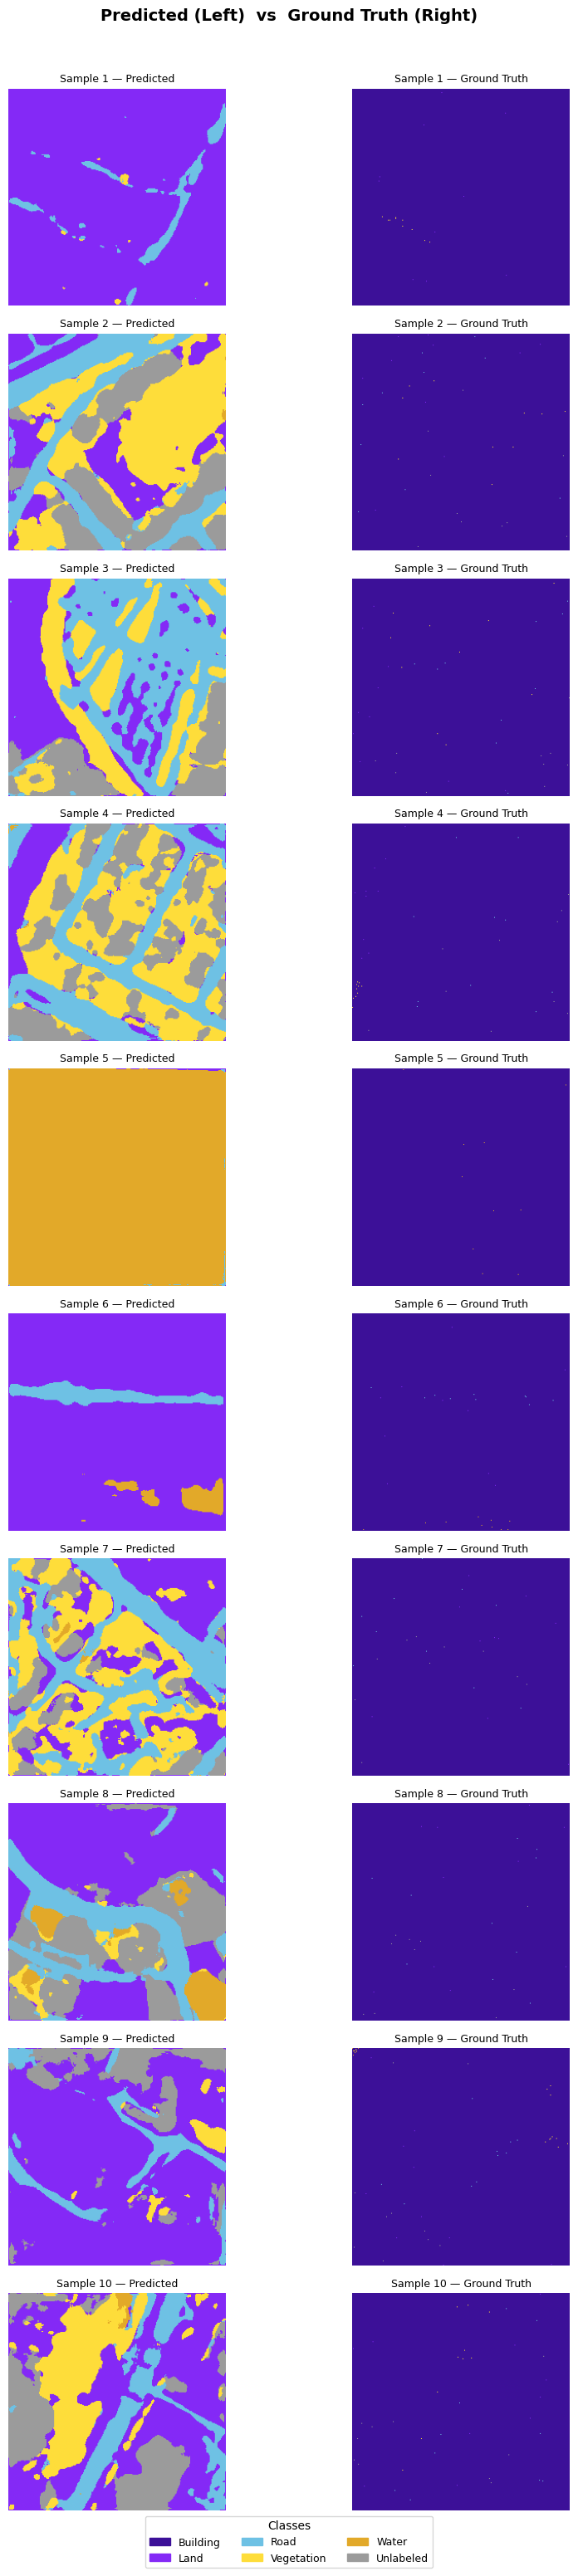

In [59]:

import ttach as tta



tta_transforms = tta.Compose([
    tta.HorizontalFlip(),
    tta.VerticalFlip(),
    tta.Rotate90(angles=[0, 90, 180, 270]),
])
test_mIoU, test_loss = run_inference_on_test(
    X_test, y_test,
    results[-1]['model_a'].to(device), results[-1]['model_b'].to(device),
    tta_transforms,
    device,
    num_display=10,
    batch_size=8
)